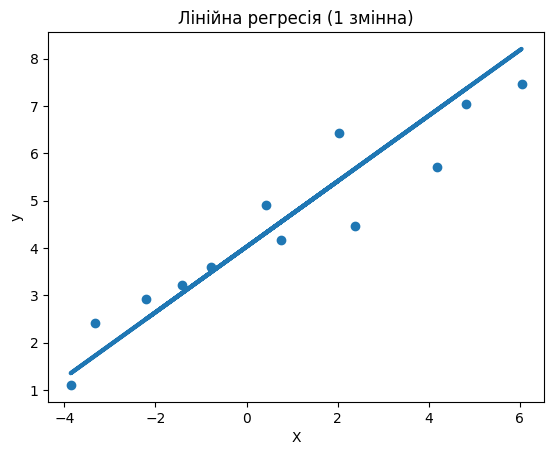

Оцінка якості лінійного регресора:
Середня абсолютна помилка = 0.59
Середньоквадратична помилка = 0.49
Медіанна абсолютна помилка = 0.51
Пояснена дисперсія = 0.86
Коефіцієнт детермінації R2 = 0.86

Нова середня абсолютна помилка = 0.59


In [1]:
import pickle
import numpy as np
from sklearn import linear_model
import sklearn.metrics as sm
import matplotlib.pyplot as plt

input_file = 'data_regr_1.txt'  

data = np.loadtxt(input_file, delimiter=',')
X, y = data[:, :-1], data[:, -1]

num_training = int(0.8 * len(X))

X_train, y_train = X[:num_training], y[:num_training]
X_test, y_test = X[num_training:], y[num_training:]

regressor = linear_model.LinearRegression()
regressor.fit(X_train, y_train)

y_test_pred = regressor.predict(X_test)

plt.scatter(X_test, y_test)
plt.plot(X_test, y_test_pred, linewidth=3)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Лінійна регресія (1 змінна)")
plt.show()

print("Оцінка якості лінійного регресора:")
print("Середня абсолютна помилка =", round(sm.mean_absolute_error(y_test, y_test_pred), 2))
print("Середньоквадратична помилка =", round(sm.mean_squared_error(y_test, y_test_pred), 2))
print("Медіанна абсолютна помилка =", round(sm.median_absolute_error(y_test, y_test_pred), 2))
print("Пояснена дисперсія =", round(sm.explained_variance_score(y_test, y_test_pred), 2))
print("Коефіцієнт детермінації R2 =", round(sm.r2_score(y_test, y_test_pred), 2))

output_model_file = 'model.pkl'

with open(output_model_file, 'wb') as f:
    pickle.dump(regressor, f)

with open(output_model_file, 'rb') as f:
    regressor_model = pickle.load(f)

y_test_pred_new = regressor_model.predict(X_test)

print("\nНова середня абсолютна помилка =", round(sm.mean_absolute_error(y_test, y_test_pred_new), 2))